# SIM2 angle/colour cosine comparisons

This notebook mirrors the SIM 2 image perturbation figures by focusing on the four Jeep paint colours and the Wolf reference rendered at 45° increments. We compute CLIP embeddings to compare how colour and pose influence similarity, first deterministically and then under Monte Carlo dropout (`p=0.01`, 32 passes).

In [ ]:
%pip install -r ../requirements.txt
%pip install -e ..
print('Environment bootstrap complete. Installed requirements and editable package.')

In [14]:
import sys
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.animation import FuncAnimation
import seaborn as sns

NOTEBOOK_ROOT = Path.cwd()
REPO_ROOT = NOTEBOOK_ROOT if (NOTEBOOK_ROOT / 'src').exists() else NOTEBOOK_ROOT.parent
SRC_ROOT = REPO_ROOT / 'src'
for path in (REPO_ROOT, SRC_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

pd.set_option('display.precision', 4)
print(f'Repository root: {REPO_ROOT}')

Repository root: /home/fwromano/Documents/Code/UCLIP


In [15]:
DATA_ROOT = REPO_ROOT / 'data/car_sim/sim2_cropped_45deg'
if not DATA_ROOT.exists():
    raise FileNotFoundError(f'Dataset not found at {DATA_ROOT}')

TARGET_COLOURS = ['Indigo', 'Magenta', 'White', 'Yellow', 'Wolf2']
DISPLAY_NAMES = {'Wolf2': 'Wolf'}

def _parse_angle(path: Path) -> int:
    token = path.stem.split('_')[-1]
    try:
        return int(token)
    except ValueError as exc:
        raise ValueError(f'Could not parse angle from {path.name}') from exc

records = []
for path in sorted(DATA_ROOT.glob('*/*.png')):
    colour = path.parent.name
    if colour not in TARGET_COLOURS:
        continue
    angle = _parse_angle(path)
    records.append({
        'color': colour,
        'display_color': DISPLAY_NAMES.get(colour, colour),
        'angle': angle,
        'path': path,
    })

dataset_df = pd.DataFrame(records).sort_values(['color', 'angle']).reset_index(drop=True)
angles = sorted(dataset_df['angle'].unique().tolist())
colours = [colour for colour in TARGET_COLOURS if colour in dataset_df['color'].unique()]
print(f'Loaded {len(dataset_df)} images spanning {len(colours)} colours and {len(angles)} angles.')
display(dataset_df.head())


CACHE_ROOT = REPO_ROOT / 'runs' / 'sim2_angle_colour_cosine'
CACHE_ROOT.mkdir(parents=True, exist_ok=True)


Loaded 40 images spanning 5 colours and 8 angles.


,color,display_color,angle,path
0,Indigo,Indigo,0,/home/fwromano/Documents/Code/UCLIP/data/car_s...
1,Indigo,Indigo,45,/home/fwromano/Documents/Code/UCLIP/data/car_s...
2,Indigo,Indigo,90,/home/fwromano/Documents/Code/UCLIP/data/car_s...
3,Indigo,Indigo,135,/home/fwromano/Documents/Code/UCLIP/data/car_s...
4,Indigo,Indigo,180,/home/fwromano/Documents/Code/UCLIP/data/car_s...


## Helper utilities

In [16]:
import math

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from uclip.core.utils import load_clip_backbone, normalise_embeddings, set_determinism
from uclip.core.dropout import insert_adapters, override_dropout_rate, dump_dropout_rates
from uclip.core.sampling import sample_embeddings

sns.set_theme(style='white', context='notebook')

COLOUR_HEX = {
    'indigo': '#1f77b4',
    'magenta': '#e377c2',
    'white': '#f0f0f0',
    'yellow': '#ffd60a',
    'wolf': '#7f7f7f',
    'wolf2': '#7f7f7f',
}

CACHE_ROOT.mkdir(parents=True, exist_ok=True)

def _cache_key(colour: str, angle: int) -> str:
    return f"{colour}::{angle}"

def load_cached_embeddings(path: Path):
    if not path.exists():
        return None
    raw = torch.load(path, map_location='cpu')
    embeddings = {}
    for key, tensor in raw.items():
        if isinstance(key, str):
            colour, angle_str = key.split('::', 1)
            angle = int(angle_str)
        else:
            colour, angle = key
        embeddings[(colour, int(angle))] = tensor.clone().cpu()
    return embeddings

def save_cached_embeddings(path: Path, embeddings):
    payload = {_cache_key(colour, angle): tensor.clone().cpu() for (colour, angle), tensor in embeddings.items()}
    torch.save(payload, path)

def aggregate_vectors(vectors):
    stacked = torch.stack(vectors)
    mean = stacked.mean(dim=0, keepdim=True)
    return normalise_embeddings(mean).squeeze(0)

def compute_embeddings(df: pd.DataFrame, processor, device, generator) -> Dict[Tuple[str, int], torch.Tensor]:
    embeddings: Dict[Tuple[str, int], torch.Tensor] = {}
    for row in df.itertuples(index=False):
        with Image.open(row.path) as image:
            image = image.convert('RGB')
            inputs = processor(images=image, return_tensors='pt')
        inputs = {key: value.to(device) for key, value in inputs.items()}
        embedding = generator(inputs)
        embeddings[(row.color, row.angle)] = embedding.detach().cpu()
    return embeddings

def compute_variant_embeddings(df: pd.DataFrame, processor, device, generator, transform_fn, repeats: int = 1) -> Dict[Tuple[str, int], torch.Tensor]:
    embeddings: Dict[Tuple[str, int], torch.Tensor] = {}
    for row in df.itertuples(index=False):
        with Image.open(row.path) as image:
            base = image.convert('RGB')
        vectors = []
        for rep in range(repeats):
            transformed = transform_fn(base, row, rep)
            inputs = processor(images=transformed, return_tensors='pt')
            inputs = {key: value.to(device) for key, value in inputs.items()}
            vector = generator(inputs)
            vectors.append(vector.detach().cpu())
        embeddings[(row.color, row.angle)] = aggregate_vectors(vectors)
    return embeddings

def build_similarity_tables(embeddings: Dict[Tuple[str, int], torch.Tensor], colour_order, angle_order, display_map):
    angle_tables = {}
    for angle in angle_order:
        vectors = torch.stack([embeddings[(colour, angle)] for colour in colour_order])
        matrix = (vectors @ vectors.T).cpu().numpy()
        labels = [display_map.get(colour, colour) for colour in colour_order]
        angle_tables[angle] = pd.DataFrame(matrix, index=labels, columns=labels)
    colour_tables = {}
    for colour in colour_order:
        vectors = torch.stack([embeddings[(colour, angle)] for angle in angle_order])
        matrix = (vectors @ vectors.T).cpu().numpy()
        colour_tables[colour] = pd.DataFrame(matrix, index=angle_order, columns=angle_order)
    return angle_tables, colour_tables

def ensure_cached_embeddings(cache_path: Path, builder):
    embeddings = load_cached_embeddings(cache_path)
    if embeddings is not None:
        return embeddings, False
    embeddings = builder()
    save_cached_embeddings(cache_path, embeddings)
    return embeddings, True

def compute_value_range(tables):
    values = []
    for table in tables:
        if table is None or getattr(table, "empty", False):
            continue
        values.append(table.values)
    if not values:
        return None, None
    vmin = min(float(arr.min()) for arr in values)
    vmax = max(float(arr.max()) for arr in values)
    return vmin, vmax

def resolve_colour_palette(colour_order, display_map, fallback='colorblind'):
    if not colour_order:
        return []
    fallback_palette = sns.color_palette(fallback, n_colors=len(colour_order))
    resolved = []
    for idx, colour in enumerate(colour_order):
        candidates = [colour, display_map.get(colour, colour)]
        hex_code = None
        for candidate in candidates:
            if candidate is None:
                continue
            key = str(candidate).lower()
            hex_code = COLOUR_HEX.get(key)
            if hex_code is not None:
                break
        resolved.append(hex_code or fallback_palette[idx])
    return resolved

def _prepare_heatmap_layout(fig, title):
    top_margin = 0.9 if title else 0.98
    fig.tight_layout(rect=[0, 0, 0.88, top_margin])
    if title:
        fig.suptitle(title, fontsize=14, y=0.995)
    return top_margin

def _attach_colorbar(fig, heatmap_ref, axes_flat, count, annot_fontsize):
    if heatmap_ref is None:
        return None
    colorbar = fig.colorbar(
        heatmap_ref.collections[0],
        ax=axes_flat[:count],
        fraction=0.04,
        pad=0.02,
    )
    colorbar.ax.tick_params(labelsize=max(7, annot_fontsize - 1))
    colorbar.set_label('Cosine similarity')
    return colorbar

def plot_angle_heatmaps(
    angle_tables,
    angle_order,
    *,
    cmap='viridis',
    vmin=None,
    vmax=None,
    annot=True,
    annot_fmt='.2f',
    annot_fontsize=8,
    cols=4,
    figsize=None,
    title='Cross-colour cosine similarity by angle',
    show_colorbar=True,
):
    if not angle_order:
        raise ValueError('No angles available for plotting.')
    count = len(angle_order)
    rows = math.ceil(count / max(1, cols))
    if figsize is None:
        figsize = (cols * 4.2, rows * 4.2)
    angle_tables_list = [angle_tables[angle] for angle in angle_order]
    if vmin is None or vmax is None:
        local_vmin, local_vmax = compute_value_range(angle_tables_list)
        if vmin is None:
            vmin = local_vmin
        if vmax is None:
            vmax = local_vmax
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    heatmap_ref = None
    for idx, angle in enumerate(angle_order):
        ax = axes_flat[idx]
        table = angle_tables[angle]
        hm = sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=annot,
            fmt=annot_fmt,
            annot_kws={'fontsize': annot_fontsize},
            cbar=False,
        )
        if heatmap_ref is None:
            heatmap_ref = hm
        ax.set_title(f"{angle}° view", fontsize=12)
        is_bottom_row = idx // cols == rows - 1
        is_first_col = idx % cols == 0
        ax.set_xlabel('Comparison colour' if is_bottom_row else '')
        ax.set_ylabel('Query colour' if is_first_col else '')
        ax.tick_params(axis='both', labelsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    for ax in axes_flat[count:]:
        ax.remove()
    _prepare_heatmap_layout(fig, title)
    if show_colorbar:
        _attach_colorbar(fig, heatmap_ref, axes_flat, count, annot_fontsize)
    return fig

def plot_colour_heatmaps(
    colour_tables,
    colour_order,
    display_map,
    *,
    cmap='viridis',
    vmin=None,
    vmax=None,
    annot=True,
    annot_fmt='.2f',
    annot_fontsize=8,
    cols=3,
    figsize=None,
    title='Cross-angle cosine similarity by colour',
    show_colorbar=True,
):
    if not colour_order:
        raise ValueError('No colours available for plotting.')
    count = len(colour_order)
    rows = math.ceil(count / max(1, cols))
    if figsize is None:
        figsize = (cols * 4.2, rows * 4.2)
    colour_tables_list = [colour_tables[colour] for colour in colour_order]
    if vmin is None or vmax is None:
        local_vmin, local_vmax = compute_value_range(colour_tables_list)
        if vmin is None:
            vmin = local_vmin
        if vmax is None:
            vmax = local_vmax
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    heatmap_ref = None
    for idx, colour in enumerate(colour_order):
        ax = axes_flat[idx]
        label = display_map.get(colour, colour)
        table = colour_tables[colour]
        hm = sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=annot,
            fmt=annot_fmt,
            annot_kws={'fontsize': annot_fontsize},
            cbar=False,
        )
        if heatmap_ref is None:
            heatmap_ref = hm
        ax.set_title(f"{label} cross-angle", fontsize=12)
        is_bottom_row = idx // cols == rows - 1
        is_first_col = idx % cols == 0
        ax.set_xlabel('Comparison angle (deg)' if is_bottom_row else '')
        ax.set_ylabel('Reference angle (deg)' if is_first_col else '')
        ax.tick_params(axis='both', labelsize=9)
        tick_labels_x = [f"{angle}°" for angle in table.columns]
        tick_labels_y = [f"{angle}°" for angle in table.index]
        ax.set_xticklabels(tick_labels_x, rotation=45, ha='right')
        ax.set_yticklabels(tick_labels_y, rotation=0)
    for ax in axes_flat[count:]:
        ax.remove()
    _prepare_heatmap_layout(fig, title)
    if show_colorbar:
        _attach_colorbar(fig, heatmap_ref, axes_flat, count, annot_fontsize)
    return fig

def plot_colour_similarity_traces(
    colour_tables,
    colour_order,
    angle_order,
    display_map,
    reference_angle=None,
    *,
    ax=None,
    marker='o',
    title=None,
    annotate_peaks=True,
):
    if not angle_order:
        raise ValueError('Angle order cannot be empty.')
    if reference_angle is None:
        reference_angle = angle_order[0]
    if reference_angle not in angle_order:
        raise ValueError(f"Reference angle {reference_angle}° is not in the angle list.")
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure
    palette = resolve_colour_palette(colour_order, display_map)
    all_values = []
    for idx, colour in enumerate(colour_order):
        table = colour_tables.get(colour)
        if table is None or reference_angle not in table.index:
            continue
        series = table.loc[reference_angle, angle_order]
        values = series.values.astype(float)
        all_values.extend(values.tolist())
        colour_name = display_map.get(colour, colour)
        ax.plot(angle_order, values, marker=marker, label=colour_name, color=palette[idx % len(palette)], linewidth=1.8)
        ax.scatter(angle_order, values, color=palette[idx % len(palette)], s=30)
        if annotate_peaks and values.size:
            peak_idx = int(np.argmax(values))
            peak_angle = angle_order[peak_idx]
            peak_val = values[peak_idx]
            ax.annotate(
                f"{peak_val:.3f}",
                xy=(peak_angle, peak_val),
                xytext=(0, 8),
                textcoords='offset points',
                ha='center',
                fontsize=9,
                color=palette[idx % len(palette)],
            )
    ax.axvline(reference_angle, color='black', linestyle='--', linewidth=1, alpha=0.3, label=f'Reference {reference_angle}°')
    ax.set_xticks(angle_order)
    ax.set_xlabel('Angle (deg)')
    ax.set_ylabel('Cosine similarity')
    if title is None:
        title = f'Self-similarity relative to {reference_angle}°'
    ax.set_title(title)
    if all_values:
        ymin = min(all_values)
        ymax = max(all_values)
        margin = max(0.01, (ymax - ymin) * 0.08)
        ax.set_ylim(ymin - margin, min(1.05, ymax + margin))
    ax.grid(True, which='both', alpha=0.25)
    ax.legend(title='Colour', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    return fig, ax

def plot_colour_similarity_facets(
    colour_tables,
    colour_order,
    angle_order,
    display_map,
    reference_angle=None,
    *,
    cols=2,
    figsize=None,
    marker='o',
    title=None,
    annotate_peaks=True,
):
    if not angle_order:
        raise ValueError('Angle order cannot be empty.')
    if reference_angle is None:
        reference_angle = angle_order[0]
    data = []
    for colour in colour_order:
        table = colour_tables.get(colour)
        if table is None or reference_angle not in table.index:
            continue
        series = table.loc[reference_angle, angle_order]
        data.append((colour, series))
    if not data:
        raise ValueError('No valid colours found for plotting self-similarity.')
    count = len(data)
    rows = math.ceil(count / max(1, cols))
    if figsize is None:
        figsize = (cols * 4.4, rows * 3.6)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False, sharex=True, sharey=True)
    axes_flat = axes.flatten()
    palette = resolve_colour_palette([colour for colour, _ in data], display_map)
    all_values = np.concatenate([series.values.astype(float) for _, series in data])
    ymin = float(all_values.min())
    ymax = float(all_values.max())
    margin = max(0.01, (ymax - ymin) * 0.08)
    for idx, (colour, series) in enumerate(data):
        ax = axes_flat[idx]
        values = series.loc[angle_order].values.astype(float)
        ax.axvline(reference_angle, color='black', linestyle='--', linewidth=1, alpha=0.3)
        ax.plot(angle_order, values, marker=marker, color=palette[idx % len(palette)], linewidth=1.8)
        ax.scatter(angle_order, values, color=palette[idx % len(palette)], s=30)
        if annotate_peaks and values.size:
            peak_idx = int(np.argmax(values))
            peak_angle = angle_order[peak_idx]
            peak_val = values[peak_idx]
            ax.annotate(
                f"{peak_angle}°\n{peak_val:.3f}",
                xy=(peak_angle, peak_val),
                xytext=(0, 8),
                textcoords='offset points',
                ha='center',
                fontsize=8,
                color=palette[idx % len(palette)],
            )
        ax.set_title(display_map.get(colour, colour))
        if idx // cols == rows - 1:
            ax.set_xlabel('Angle (deg)')
        else:
            ax.set_xlabel('')
        if idx % cols == 0:
            ax.set_ylabel('Cosine similarity')
        else:
            ax.set_ylabel('')
        ax.set_xticks(angle_order)
        ax.set_ylim(ymin - margin, min(1.05, ymax + margin))
        ax.tick_params(axis='both', labelsize=9)
        ax.grid(True, which='both', alpha=0.25)
    for ax in axes_flat[count:]:
        ax.remove()
    if title is None:
        title = f'Self-similarity per colour (reference {reference_angle}°)'
    fig.suptitle(title, fontsize=14, y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

def _build_directional_path(angle_order, base_angle, direction):
    if not angle_order:
        raise ValueError('Angle order cannot be empty.')
    if base_angle not in angle_order:
        raise ValueError(f"Base angle {base_angle}° is not in the angle list.")
    start_idx = angle_order.index(base_angle)
    rotated = angle_order[start_idx:] + angle_order[:start_idx]
    if direction == 'forward':
        return rotated
    if direction == 'backward':
        head, tail = rotated[0], rotated[1:]
        return [head] + tail[::-1]
    raise ValueError(f"Unknown direction '{direction}'.")

def plot_directional_angle_transitions(
    colour_tables,
    colour_order,
    angle_order,
    display_map,
    *,
    base_angle=None,
    directions=('forward', 'backward'),
    marker='o',
    figsize=None,
):
    if base_angle is None:
        base_angle = angle_order[0]
    if not directions:
        raise ValueError('At least one direction must be provided.')
    summary = []
    all_values = []
    for direction in directions:
        path = _build_directional_path(angle_order, base_angle, direction)
        if len(path) < 2:
            raise ValueError('Need at least two angles to compute transitions.')
        pair_labels = [f"{src}→{dst}" for src, dst in zip(path[:-1], path[1:])]
        colour_series = []
        for colour in colour_order:
            table = colour_tables.get(colour)
            if table is None:
                continue
            values = [float(table.loc[src, dst]) for src, dst in zip(path[:-1], path[1:])]
            all_values.extend(values)
            colour_series.append((colour, values))
        summary.append((direction, pair_labels, colour_series))
    if not all_values:
        raise ValueError('No valid angle transitions found for plotting.')
    ymin = min(all_values)
    ymax = max(all_values)
    margin = max(0.01, (ymax - ymin) * 0.1)
    ylim = (ymin - margin, min(1.05, ymax + margin))
    if figsize is None:
        figsize = (6 * len(summary), 4.5)
    fig, axes = plt.subplots(1, len(summary), figsize=figsize, sharey=True)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    palette = resolve_colour_palette(colour_order, display_map)
    for ax, (direction, pair_labels, colour_series) in zip(axes, summary):
        x = list(range(len(pair_labels)))
        for idx, (colour, values) in enumerate(colour_series):
            label = display_map.get(colour, colour)
            ax.plot(x, values, marker=marker, linewidth=1.8, color=palette[idx % len(palette)], label=label)
            ax.scatter(x, values, color=palette[idx % len(palette)], s=30)
        ax.set_xticks(x)
        ax.set_xticklabels(pair_labels, rotation=45, ha='right')
        ax.set_ylim(ylim)
        ax.set_xlabel('Angle transition')
        ax.grid(True, which='both', alpha=0.25)
        title_label = 'Forward (+45°)' if direction == 'forward' else 'Backward (-45°)'
        ax.set_title(title_label)
    axes[0].set_ylabel('Cosine similarity')
    handles, labels = axes[-1].get_legend_handles_labels()
    if handles:
        axes[-1].legend(handles, labels, title='Colour', bbox_to_anchor=(1.02, 1), loc='upper left')
    fig.tight_layout()
    return fig

def plot_cross_colour_difference_heatmaps(
    angle_tables,
    angle_order,
    reference_angle,
    display_map,
    *,
    cmap='coolwarm',
    annot_fmt='.2f',
    annot_fontsize=8,
    cols=4,
    figsize=None,
):
    if reference_angle not in angle_order:
        raise ValueError('Reference angle must be in the angle list.')
    base = angle_tables[reference_angle]
    diff_tables = {angle: angle_tables[angle] - base for angle in angle_order}
    max_abs = max(abs(table.values).max() for table in diff_tables.values()) or 1.0
    vmin, vmax = -max_abs, max_abs
    count = len(angle_order)
    rows = math.ceil(count / max(1, cols))
    if figsize is None:
        figsize = (cols * 4.2, rows * 4.2)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    for idx, angle in enumerate(angle_order):
        ax = axes_flat[idx]
        table = diff_tables[angle]
        sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=annot_fmt,
            annot_kws={'fontsize': annot_fontsize},
            cbar=False,
        )
        ax.set_title(f"Δ vs {reference_angle}° ({angle}°)", fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    for ax in axes_flat[count:]:
        ax.remove()
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax)), ax=axes_flat[:count], fraction=0.04, pad=0.02)
    cbar.set_label('Cosine Δ')
    fig.tight_layout()
    return fig

def plot_cross_angle_difference_heatmaps(
    colour_tables,
    colour_order,
    angle_order,
    display_map,
    reference_angle,
    *,
    cmap='coolwarm',
    annot_fmt='.2f',
    annot_fontsize=8,
    cols=3,
    figsize=None,
):
    if reference_angle not in angle_order:
        raise ValueError('Reference angle must be in the angle list.')
    diff_tables = {}
    for colour in colour_order:
        table = colour_tables[colour]
        base_row = table.loc[reference_angle]
        diff_tables[colour] = table.subtract(base_row, axis=1)
    max_abs = max(abs(table.values).max() for table in diff_tables.values()) or 1.0
    vmin, vmax = -max_abs, max_abs
    count = len(colour_order)
    rows = math.ceil(count / max(1, cols))
    if figsize is None:
        figsize = (cols * 4.2, rows * 4.2)
    fig, axes = plt.subplots(rows, cols, figsize=figsize, squeeze=False)
    axes_flat = axes.flatten()
    for idx, colour in enumerate(colour_order):
        ax = axes_flat[idx]
        label = display_map.get(colour, colour)
        table = diff_tables[colour]
        sns.heatmap(
            table,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            annot=True,
            fmt=annot_fmt,
            annot_kws={'fontsize': annot_fontsize},
            cbar=False,
        )
        ax.set_title(f"{label} Δ vs {reference_angle}°", fontsize=11)
        ax.set_xticklabels([f"{angle}°" for angle in table.columns], rotation=45, ha='right')
        ax.set_yticklabels([f"{angle}°" for angle in table.index], rotation=0)
    for ax in axes_flat[count:]:
        ax.remove()
    cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax)), ax=axes_flat[:count], fraction=0.04, pad=0.02)
    cbar.set_label('Cosine Δ')
    fig.tight_layout()
    return fig

def plot_top_match_map(angle_tables, colour_order, angle_order, display_map, *, exclude_self=True):
    labels = [display_map.get(colour, colour) for colour in colour_order]
    data = []
    for label in labels:
        row_entries = []
        for angle in angle_order:
            table = angle_tables[angle]
            row = table.loc[label]
            candidate = row.drop(label, errors='ignore') if exclude_self else row
            target = candidate.idxmax()
            row_entries.append(target)
        data.append(row_entries)
    df = pd.DataFrame(data, index=labels, columns=[f"{angle}°" for angle in angle_order])
    unique_labels = sorted({value for values in df.values for value in values})
    inverse_display = {display_map.get(colour, colour): colour for colour in colour_order}
    palette_keys = [inverse_display.get(label, label.lower()) for label in unique_labels]
    palette = resolve_colour_palette(palette_keys, display_map)
    value_map = {label: idx for idx, label in enumerate(unique_labels)}
    numeric = df.replace(value_map)
    cmap = ListedColormap(palette)
    fig, ax = plt.subplots(figsize=(len(angle_order) * 1.2, len(colour_order) * 0.8))
    sns.heatmap(
        numeric,
        ax=ax,
        cmap=cmap,
        cbar=False,
        annot=df.values,
        fmt='',
        annot_kws={'color': 'black', 'fontsize': 9, 'fontweight': 'bold'},
        linewidths=0.5,
        linecolor='black'
    )
    ax.set_xlabel('Angle (deg)')
    ax.set_ylabel('Query colour')
    ax.set_title('Most similar colour (excluding self) at each angle')
    return fig

def plot_polar_similarity_radar(colour_tables, colour_order, angle_order, display_map, reference_angle=None):
    if reference_angle is None:
        reference_angle = angle_order[0]
    if reference_angle not in angle_order:
        raise ValueError('Reference angle must be in the angle list.')
    theta = np.deg2rad(angle_order + [angle_order[0]])
    palette = resolve_colour_palette(colour_order, display_map)
    fig, axes = plt.subplots(1, len(colour_order), subplot_kw={'projection': 'polar'}, figsize=(len(colour_order) * 3.2, 4.5))
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    global_min, global_max = [], []
    for colour in colour_order:
        table = colour_tables[colour]
        series = table.loc[reference_angle, angle_order].values.astype(float)
        global_min.append(series.min())
        global_max.append(series.max())
    rmin = min(global_min)
    rmax = min(1.05, max(global_max))
    for idx, (colour, ax) in enumerate(zip(colour_order, axes)):
        table = colour_tables[colour]
        values = table.loc[reference_angle, angle_order].values.astype(float)
        values = np.append(values, values[0])
        ax.plot(theta, values, color='black', linewidth=2)
        ax.fill(theta, values, color='black', alpha=0.1)
        ax.set_title(display_map.get(colour, colour))
        ax.set_ylim(rmin * 0.95, rmax)
        ax.set_xticks(np.deg2rad(angle_order))
        ax.set_xticklabels([f"{angle}°" for angle in angle_order])
        ax.set_yticklabels([])
    fig.suptitle(f'Self-similarity radial profile (reference {reference_angle}°)', fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def build_global_similarity_matrix(embeddings, colour_order, angle_order, display_map):
    ordered_keys = []
    labels = []
    for colour in colour_order:
        for angle in angle_order:
            key = (colour, angle)
            if key not in embeddings:
                continue
            ordered_keys.append(key)
            labels.append(f"{display_map.get(colour, colour)} {angle}°")
    if not ordered_keys:
        raise ValueError('No embeddings available for global similarity heatmap.')
    vectors = torch.stack([embeddings[key] for key in ordered_keys])
    matrix = (vectors @ vectors.T).cpu().numpy()
    return matrix, labels

def plot_global_similarity_heatmap(
    embeddings,
    colour_order,
    angle_order,
    display_map,
    *,
    cmap='viridis',
    vmin=None,
    vmax=None,
    annot=True,
    annot_fmt='.2f',
    annot_fontsize=7,
    figsize=(12, 10),
    title='Cosine similarity across all colour/angle combinations',
):
    matrix, labels = build_global_similarity_matrix(embeddings, colour_order, angle_order, display_map)
    if vmin is None or vmax is None:
        local_vmin = float(matrix.min())
        local_vmax = float(matrix.max())
        if vmin is None:
            vmin = local_vmin
        if vmax is None:
            vmax = local_vmax
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        annot=annot,
        fmt=annot_fmt,
        annot_kws={'fontsize': annot_fontsize},
        cbar=True,
        cbar_kws={'label': 'Cosine similarity'},
        square=False,
        xticklabels=labels,
        yticklabels=labels,
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    ax.set_xlabel('Comparison image')
    ax.set_ylabel('Query image')
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_similarity_graph(
    embeddings,
    colour_order,
    angle_order,
    display_map,
    *,
    threshold=0.97,
):
    matrix, labels = build_global_similarity_matrix(embeddings, colour_order, angle_order, display_map)
    n = len(labels)
    edges = []
    weights = []
    for i in range(n):
        for j in range(i + 1, n):
            value = matrix[i, j]
            if value >= threshold:
                edges.append((i, j))
                weights.append(value)
    if not edges:
        raise ValueError(f'No edges found above threshold {threshold:.2f}. Try lowering the threshold.')
    palette = resolve_colour_palette(colour_order, display_map)
    colour_lookup = {colour: palette[idx % len(palette)] for idx, colour in enumerate(colour_order)}
    node_colors = []
    base_labels = []
    for label in labels:
        base = label.split()[0]
        base_colour = None
        for key, value in display_map.items():
            if value == base:
                base_colour = key
                break
        base_labels.append(base)
        node_colors.append(colour_lookup.get(base_colour or base.lower(), '#7f7f7f'))
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    radius = 1.0
    positions = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_aspect('equal')
    for (i, j), value in zip(edges, weights):
        x = positions[[i, j], 0]
        y = positions[[i, j], 1]
        width = 0.5 + 3.5 * (value - threshold) / (1 - threshold + 1e-6)
        ax.plot(x, y, color='gray', linewidth=width, alpha=0.4)
    ax.scatter(positions[:, 0], positions[:, 1], s=280, c=node_colors, edgecolors='black')
    for idx, (x, y) in enumerate(positions):
        ax.text(x, y, labels[idx], fontsize=8, ha='center', va='center', color='white', weight='bold')
    ax.set_title(f'Similarity graph (threshold ≥ {threshold:.2f})')
    ax.axis('off')
    fig.tight_layout()
    return fig

def animate_angle_sweep(
    angle_tables,
    colour_order,
    angle_order,
    display_map,
    *,
    base_colour,
    interval=800,
):
    base_label = display_map.get(base_colour, base_colour)
    labels = [display_map.get(colour, colour) for colour in colour_order]
    palette = resolve_colour_palette(colour_order, display_map)
    all_values = []
    for angle in angle_order:
        table = angle_tables[angle]
        series = table.loc[base_label, labels]
        all_values.extend(series.values.tolist())
    ymax = min(1.05, max(all_values) + 0.05)
    fig, ax = plt.subplots(figsize=(6, 4))
    x = np.arange(len(labels))
    bars = ax.bar(x, np.zeros_like(x), color=palette)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylim(0, ymax)
    ax.set_ylabel('Cosine similarity')

    def update(frame):
        angle = angle_order[frame]
        table = angle_tables[angle]
        values = table.loc[base_label, labels].values.astype(float)
        for bar, value in zip(bars, values):
            bar.set_height(value)
        ax.set_title(f'{base_label} compared across colours — {angle}° view')
        return bars

    anim = FuncAnimation(fig, update, frames=len(angle_order), interval=interval, blit=False, repeat=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


## Deterministic CLIP embeddings

In [17]:
MODEL_ID = 'openai/clip-vit-base-patch32'
DEVICE = None  # set to 'cuda' to force GPU usage
SEED = 20240410

DET_CACHE_PATH = CACHE_ROOT / f"{MODEL_ID.replace('/', '_')}_deterministic.pt"

det_embeddings = load_cached_embeddings(DET_CACHE_PATH)
if det_embeddings is not None:
    print(f'Loaded deterministic embeddings from cache: {DET_CACHE_PATH}')
else:
    set_determinism(SEED)
    loaded = load_clip_backbone(MODEL_ID, device=DEVICE)
    model_det, processor_det, device_det = loaded.model, loaded.processor, loaded.device
    model_det.eval()

    def deterministic_generator(inputs):
        with torch.no_grad():
            embedding = model_det.get_image_features(**inputs)
        embedding = normalise_embeddings(embedding).squeeze(0)
        return embedding

    det_embeddings = compute_embeddings(dataset_df, processor_det, device_det, deterministic_generator)
    save_cached_embeddings(DET_CACHE_PATH, det_embeddings)
    print(f'Deterministic embeddings computed and cached at {DET_CACHE_PATH}')

if det_embeddings is None:
    raise RuntimeError('Deterministic embeddings unavailable after attempted computation.')

angle_tables_det, colour_tables_det = build_similarity_tables(det_embeddings, colours, angles, DISPLAY_NAMES)
print('Deterministic embeddings ready for similarity analysis.')


Loaded deterministic embeddings from cache: /home/fwromano/Documents/Code/UCLIP/runs/sim2_angle_colour_cosine/openai_clip-vit-base-patch32_deterministic.pt
Deterministic embeddings ready for similarity analysis.


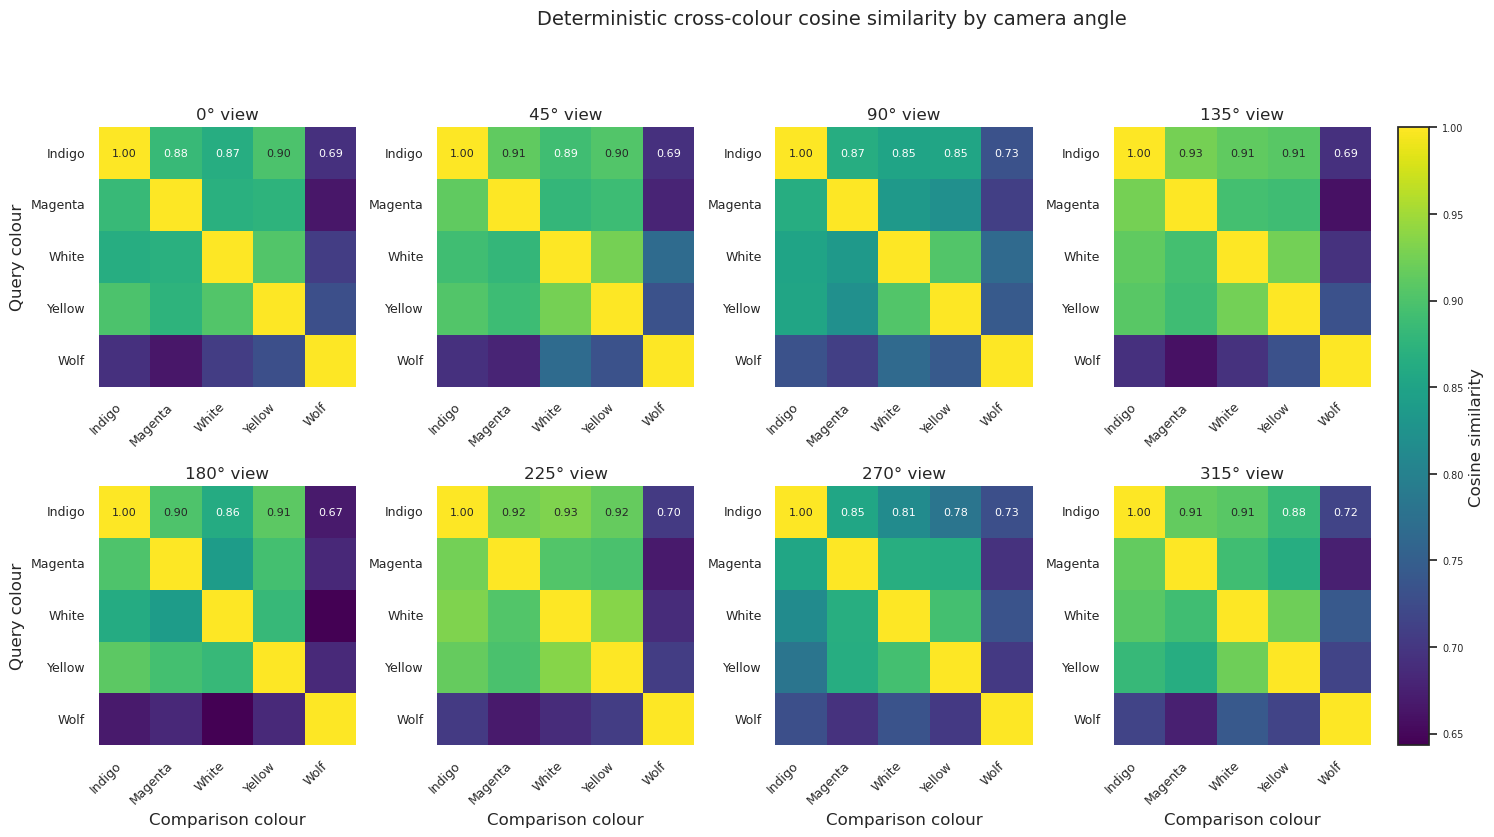

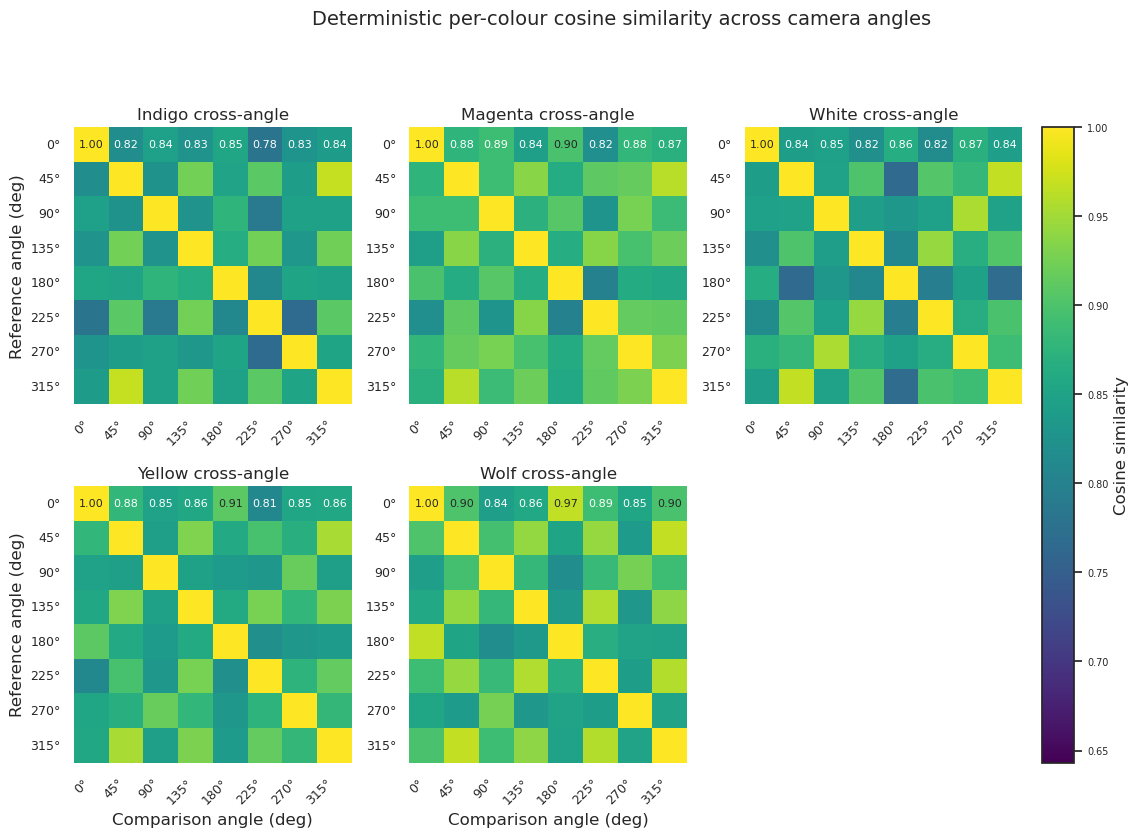

In [18]:
det_tables = list(angle_tables_det.values()) + list(colour_tables_det.values())
if not det_tables:
    raise ValueError('No deterministic similarity tables available.')
det_vmin, det_vmax = compute_value_range(det_tables)

plot_angle_heatmaps(
    angle_tables_det,
    angles,
    vmin=det_vmin,
    vmax=det_vmax,
    title='Deterministic cross-colour cosine similarity by camera angle',
)
plt.show()

plot_colour_heatmaps(
    colour_tables_det,
    colours,
    DISPLAY_NAMES,
    vmin=det_vmin,
    vmax=det_vmax,
    title='Deterministic per-colour cosine similarity across camera angles',
)
plt.show()


### Visual heatmaps and angle traces

The tables above are precise but hard to scan. These plots provide heatmaps for cross-colour and cross-angle cosine similarities with consistent colour bars and data labels, plus line traces that highlight each colour's peak similarity as the viewpoint changes.

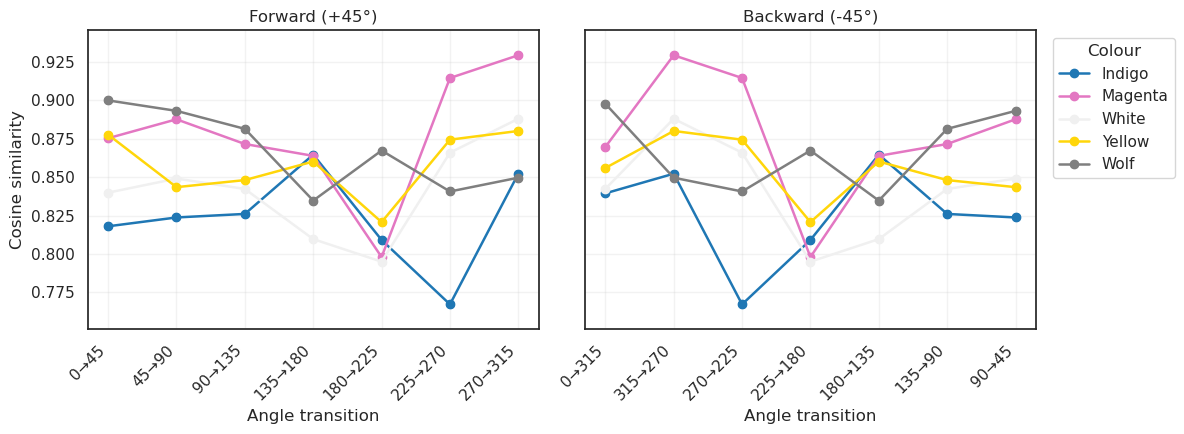

In [19]:
# Self-similarity transitions between neighbouring viewpoints
base_angle = angles[0]

directional_fig = plot_directional_angle_transitions(
    colour_tables_det,
    colours,
    angles,
    DISPLAY_NAMES,
    base_angle=base_angle,
    directions=('forward', 'backward'),
)
plt.show()


In [20]:
MC_DROPOUT_P = 0.01
MC_PASSES = 32
MC_MICROBATCH = 4
ADAPTER_TARGETS = [f'vision_model.encoder.layers.{idx}' for idx in range(12)] + ['visual_projection']

mc_cache_name = f"{MODEL_ID.replace('/', '_')}_mcdo_p{MC_DROPOUT_P}_passes{MC_PASSES}.pt"
MC_CACHE_PATH = CACHE_ROOT / mc_cache_name

mcdo_embeddings = load_cached_embeddings(MC_CACHE_PATH)
if mcdo_embeddings is not None:
    print(f'Loaded MC dropout embeddings from cache: {MC_CACHE_PATH}')
else:
    set_determinism(SEED)
    loaded_mc = load_clip_backbone(MODEL_ID, device=DEVICE)
    model_mc, processor_mc, device_mc = loaded_mc.model, loaded_mc.processor, loaded_mc.device
    model_mc.eval()
    insert_adapters(model_mc, ADAPTER_TARGETS, p=MC_DROPOUT_P)
    override_dropout_rate(model_mc, MC_DROPOUT_P)
    dropout_count, dropout_rates = dump_dropout_rates(model_mc)
    if dropout_rates:
        print(f'Detected {dropout_count} dropout layers with rates between {min(dropout_rates):.4f} and {max(dropout_rates):.4f}.')
    else:
        print('No dropout layers detected; MC dropout adapters may not have been inserted as expected.')

    def mcdo_generator(inputs):
        samples = sample_embeddings(
            model=model_mc,
            forward_fn=model_mc.get_image_features,
            forward_kwargs=inputs,
            passes=MC_PASSES,
            microbatch=MC_MICROBATCH,
        )
        model_mc.eval()
        samples = normalise_embeddings(samples)
        mean_embed = samples.mean(dim=0, keepdim=True)
        mean_embed = normalise_embeddings(mean_embed).squeeze(0)
        return mean_embed

    mcdo_embeddings = compute_embeddings(dataset_df, processor_mc, device_mc, mcdo_generator)
    save_cached_embeddings(MC_CACHE_PATH, mcdo_embeddings)
    print(f'MC dropout embeddings computed and cached at {MC_CACHE_PATH}')

if mcdo_embeddings is None:
    raise RuntimeError('MC dropout embeddings unavailable after attempted computation.')

angle_tables_mcdo, colour_tables_mcdo = build_similarity_tables(mcdo_embeddings, colours, angles, DISPLAY_NAMES)
print('Monte Carlo dropout means ready for similarity analysis.')


Loaded MC dropout embeddings from cache: /home/fwromano/Documents/Code/UCLIP/runs/sim2_angle_colour_cosine/openai_clip-vit-base-patch32_mcdo_p0.01_passes32.pt
Monte Carlo dropout means ready for similarity analysis.


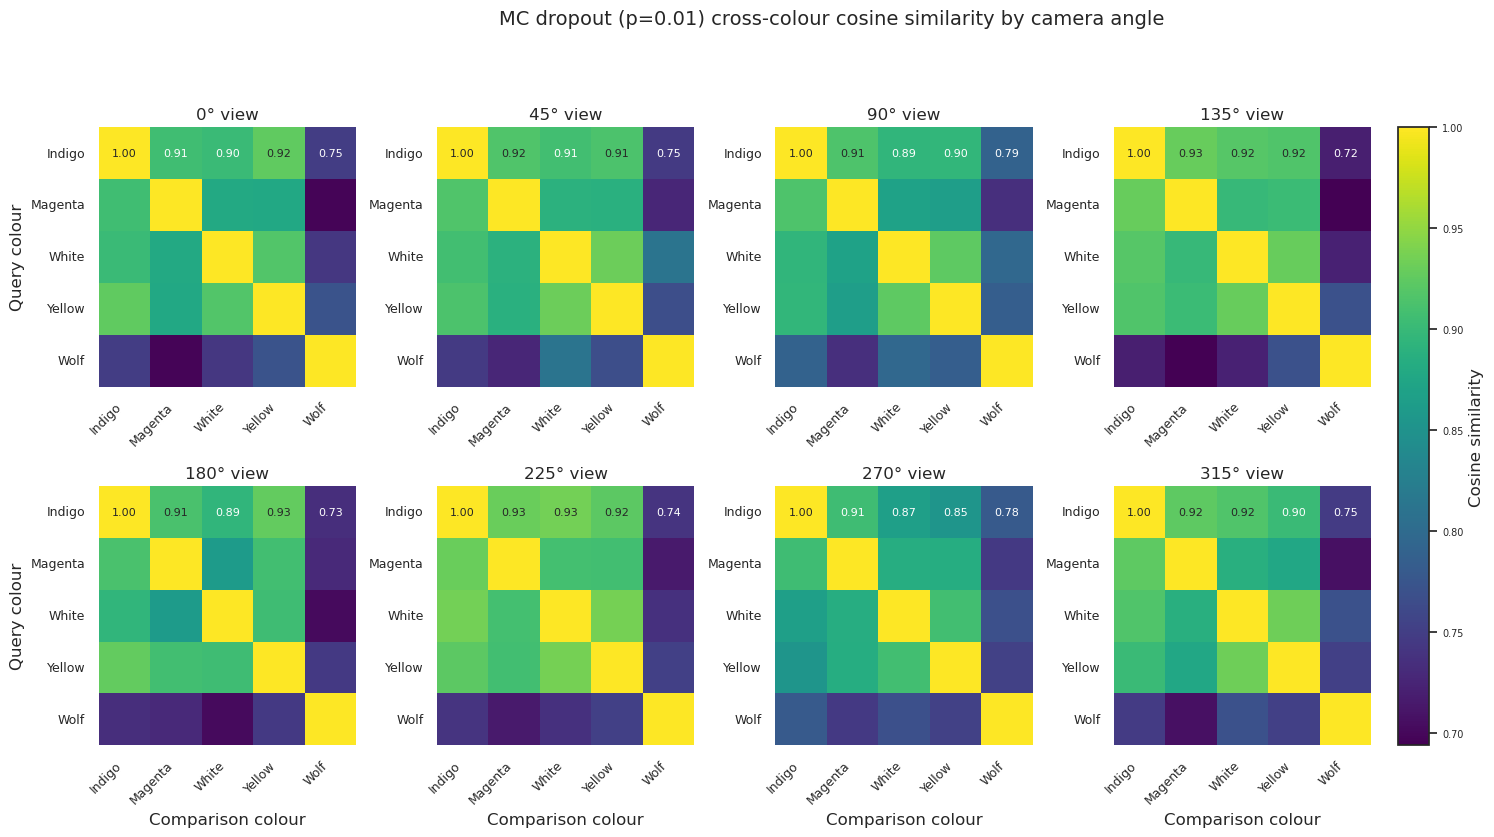

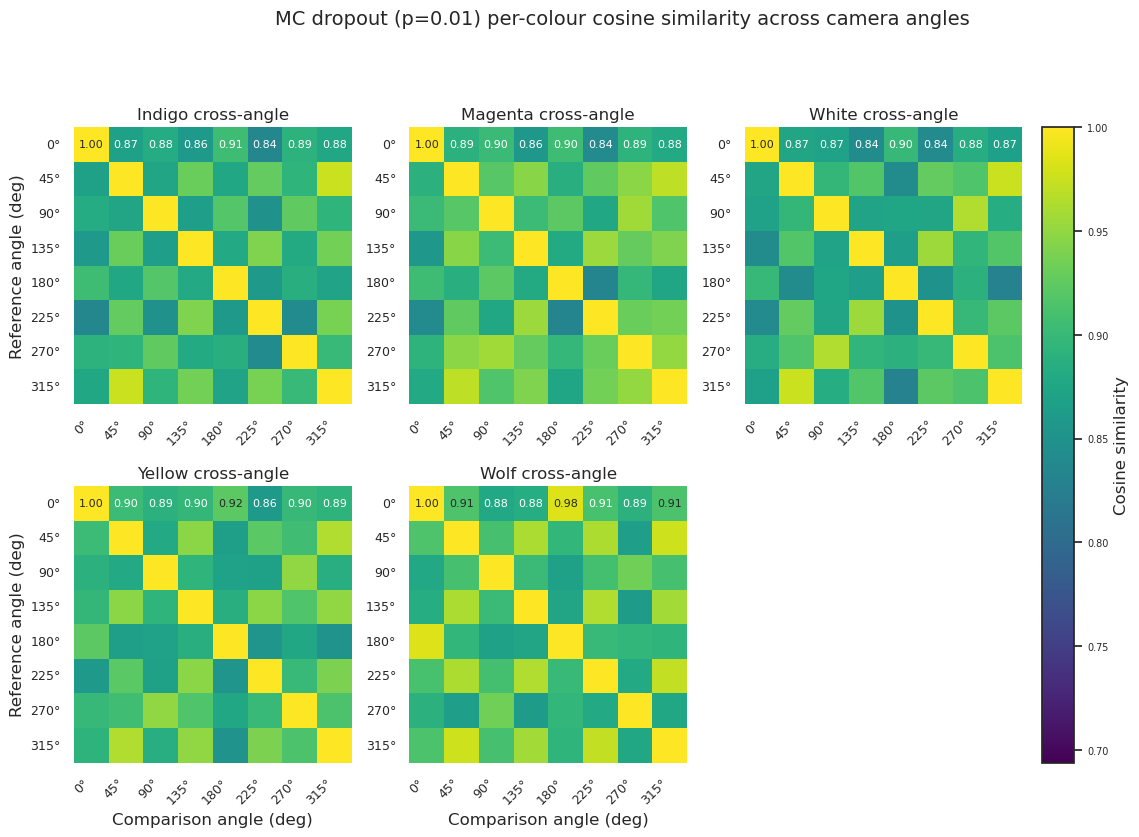

In [21]:
mc_tables = list(angle_tables_mcdo.values()) + list(colour_tables_mcdo.values())
if not mc_tables:
    raise ValueError('No MC dropout similarity tables available.')
mc_vmin, mc_vmax = compute_value_range(mc_tables)
plot_angle_heatmaps(
    angle_tables_mcdo,
    angles,
    vmin=mc_vmin,
    vmax=mc_vmax,
    title='MC dropout (p=0.01) cross-colour cosine similarity by camera angle',
)
plt.show()
plot_colour_heatmaps(
    colour_tables_mcdo,
    colours,
    DISPLAY_NAMES,
    vmin=mc_vmin,
    vmax=mc_vmax,
    title='MC dropout (p=0.01) per-colour cosine similarity across camera angles',
)
plt.show()


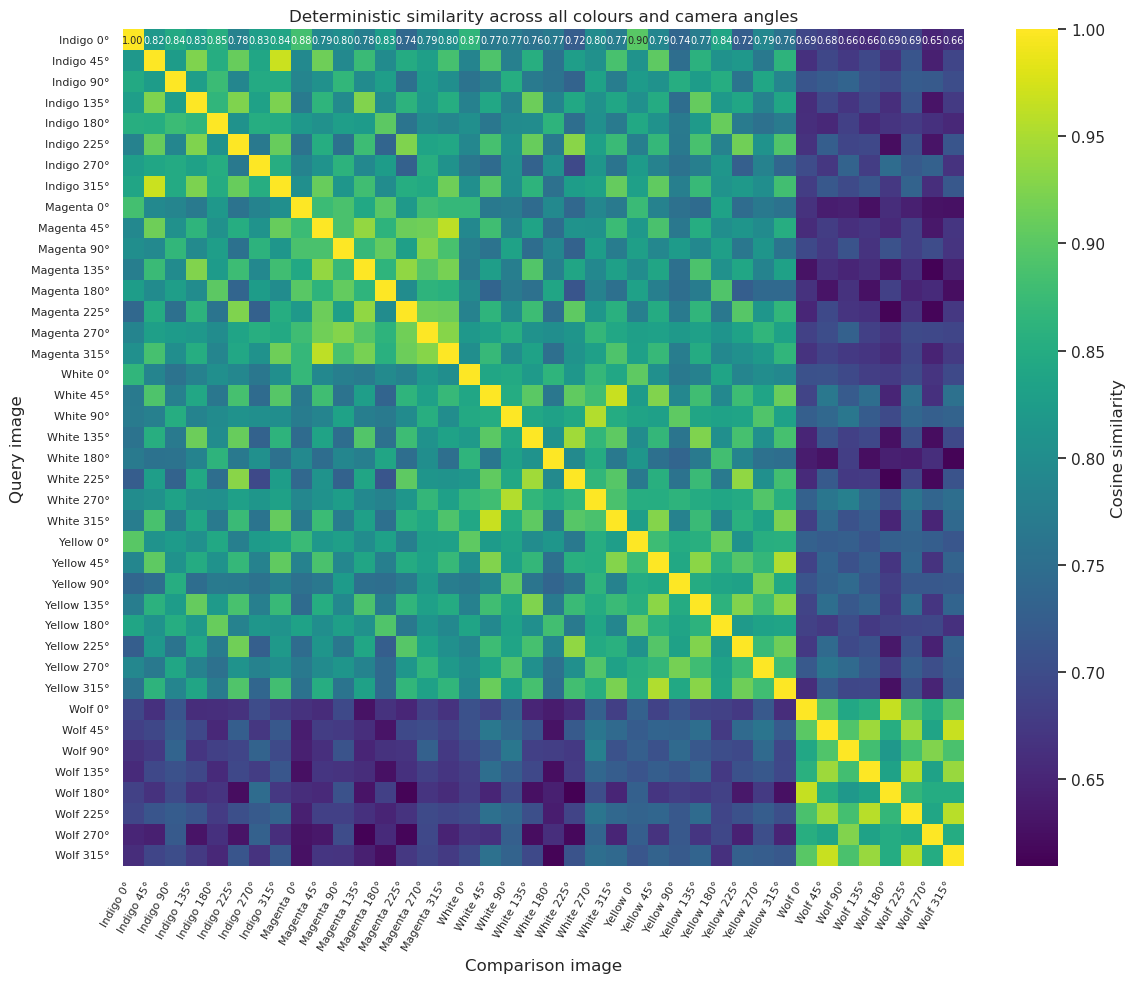

In [22]:
# Global similarity heatmap across every colour/angle combination
plot_global_similarity_heatmap(
    det_embeddings,
    colours,
    angles,
    DISPLAY_NAMES,
    title='Deterministic similarity across all colours and camera angles',
)
plt.show()


## Additional diagnostics

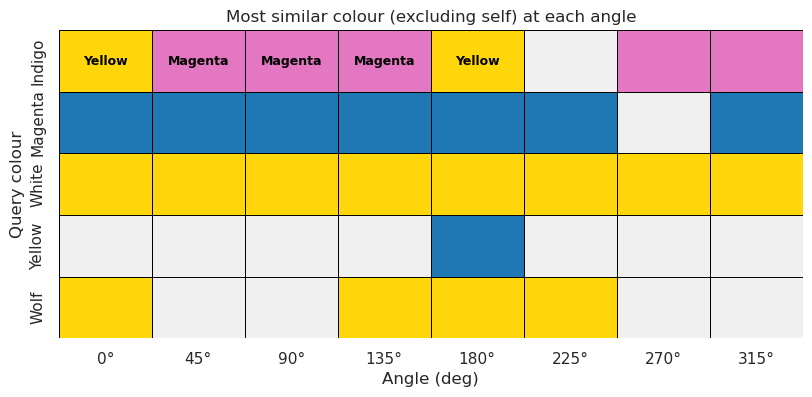

In [23]:

# Categorical view of the most similar colour (excluding self) for each angle
plot_top_match_map(
    angle_tables_det,
    colours,
    angles,
    DISPLAY_NAMES,
)
plt.show()


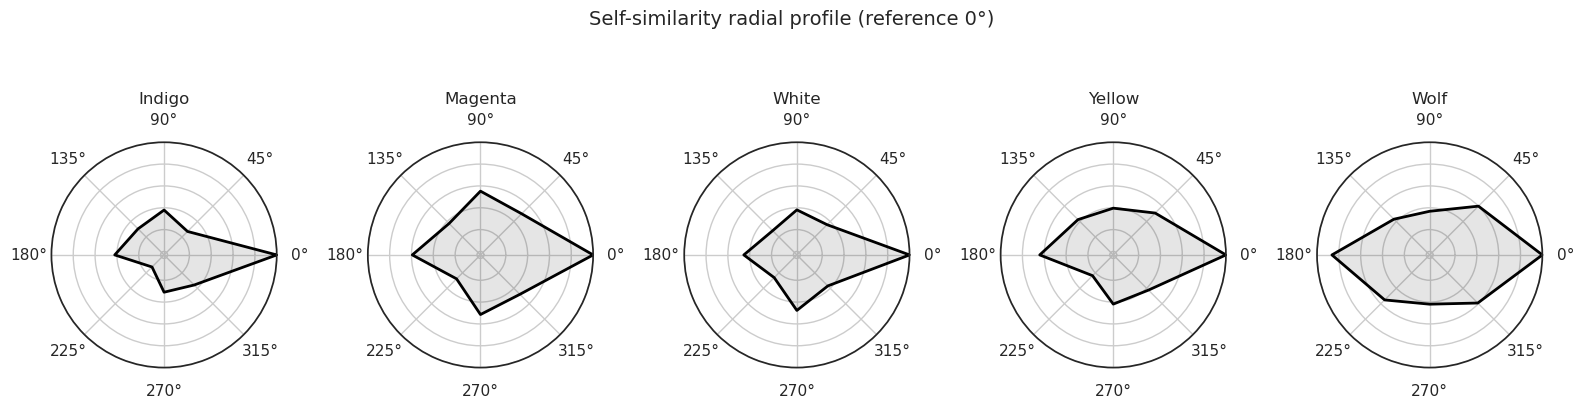

In [24]:

# Polar overview of similarity drop-offs relative to the baseline angle
plot_polar_similarity_radar(
    colour_tables_det,
    colours,
    angles,
    DISPLAY_NAMES,
    reference_angle=angles[0],
)
plt.show()
